Matrix shape in memory: (62, 4460)


,genomic_layer,gene_count,percentage_of_total
0,Core,1885,42.264574
1,Shell,963,21.591928
2,Cloud,1612,36.143498
3,Total_Pangenome,4460,100.000000


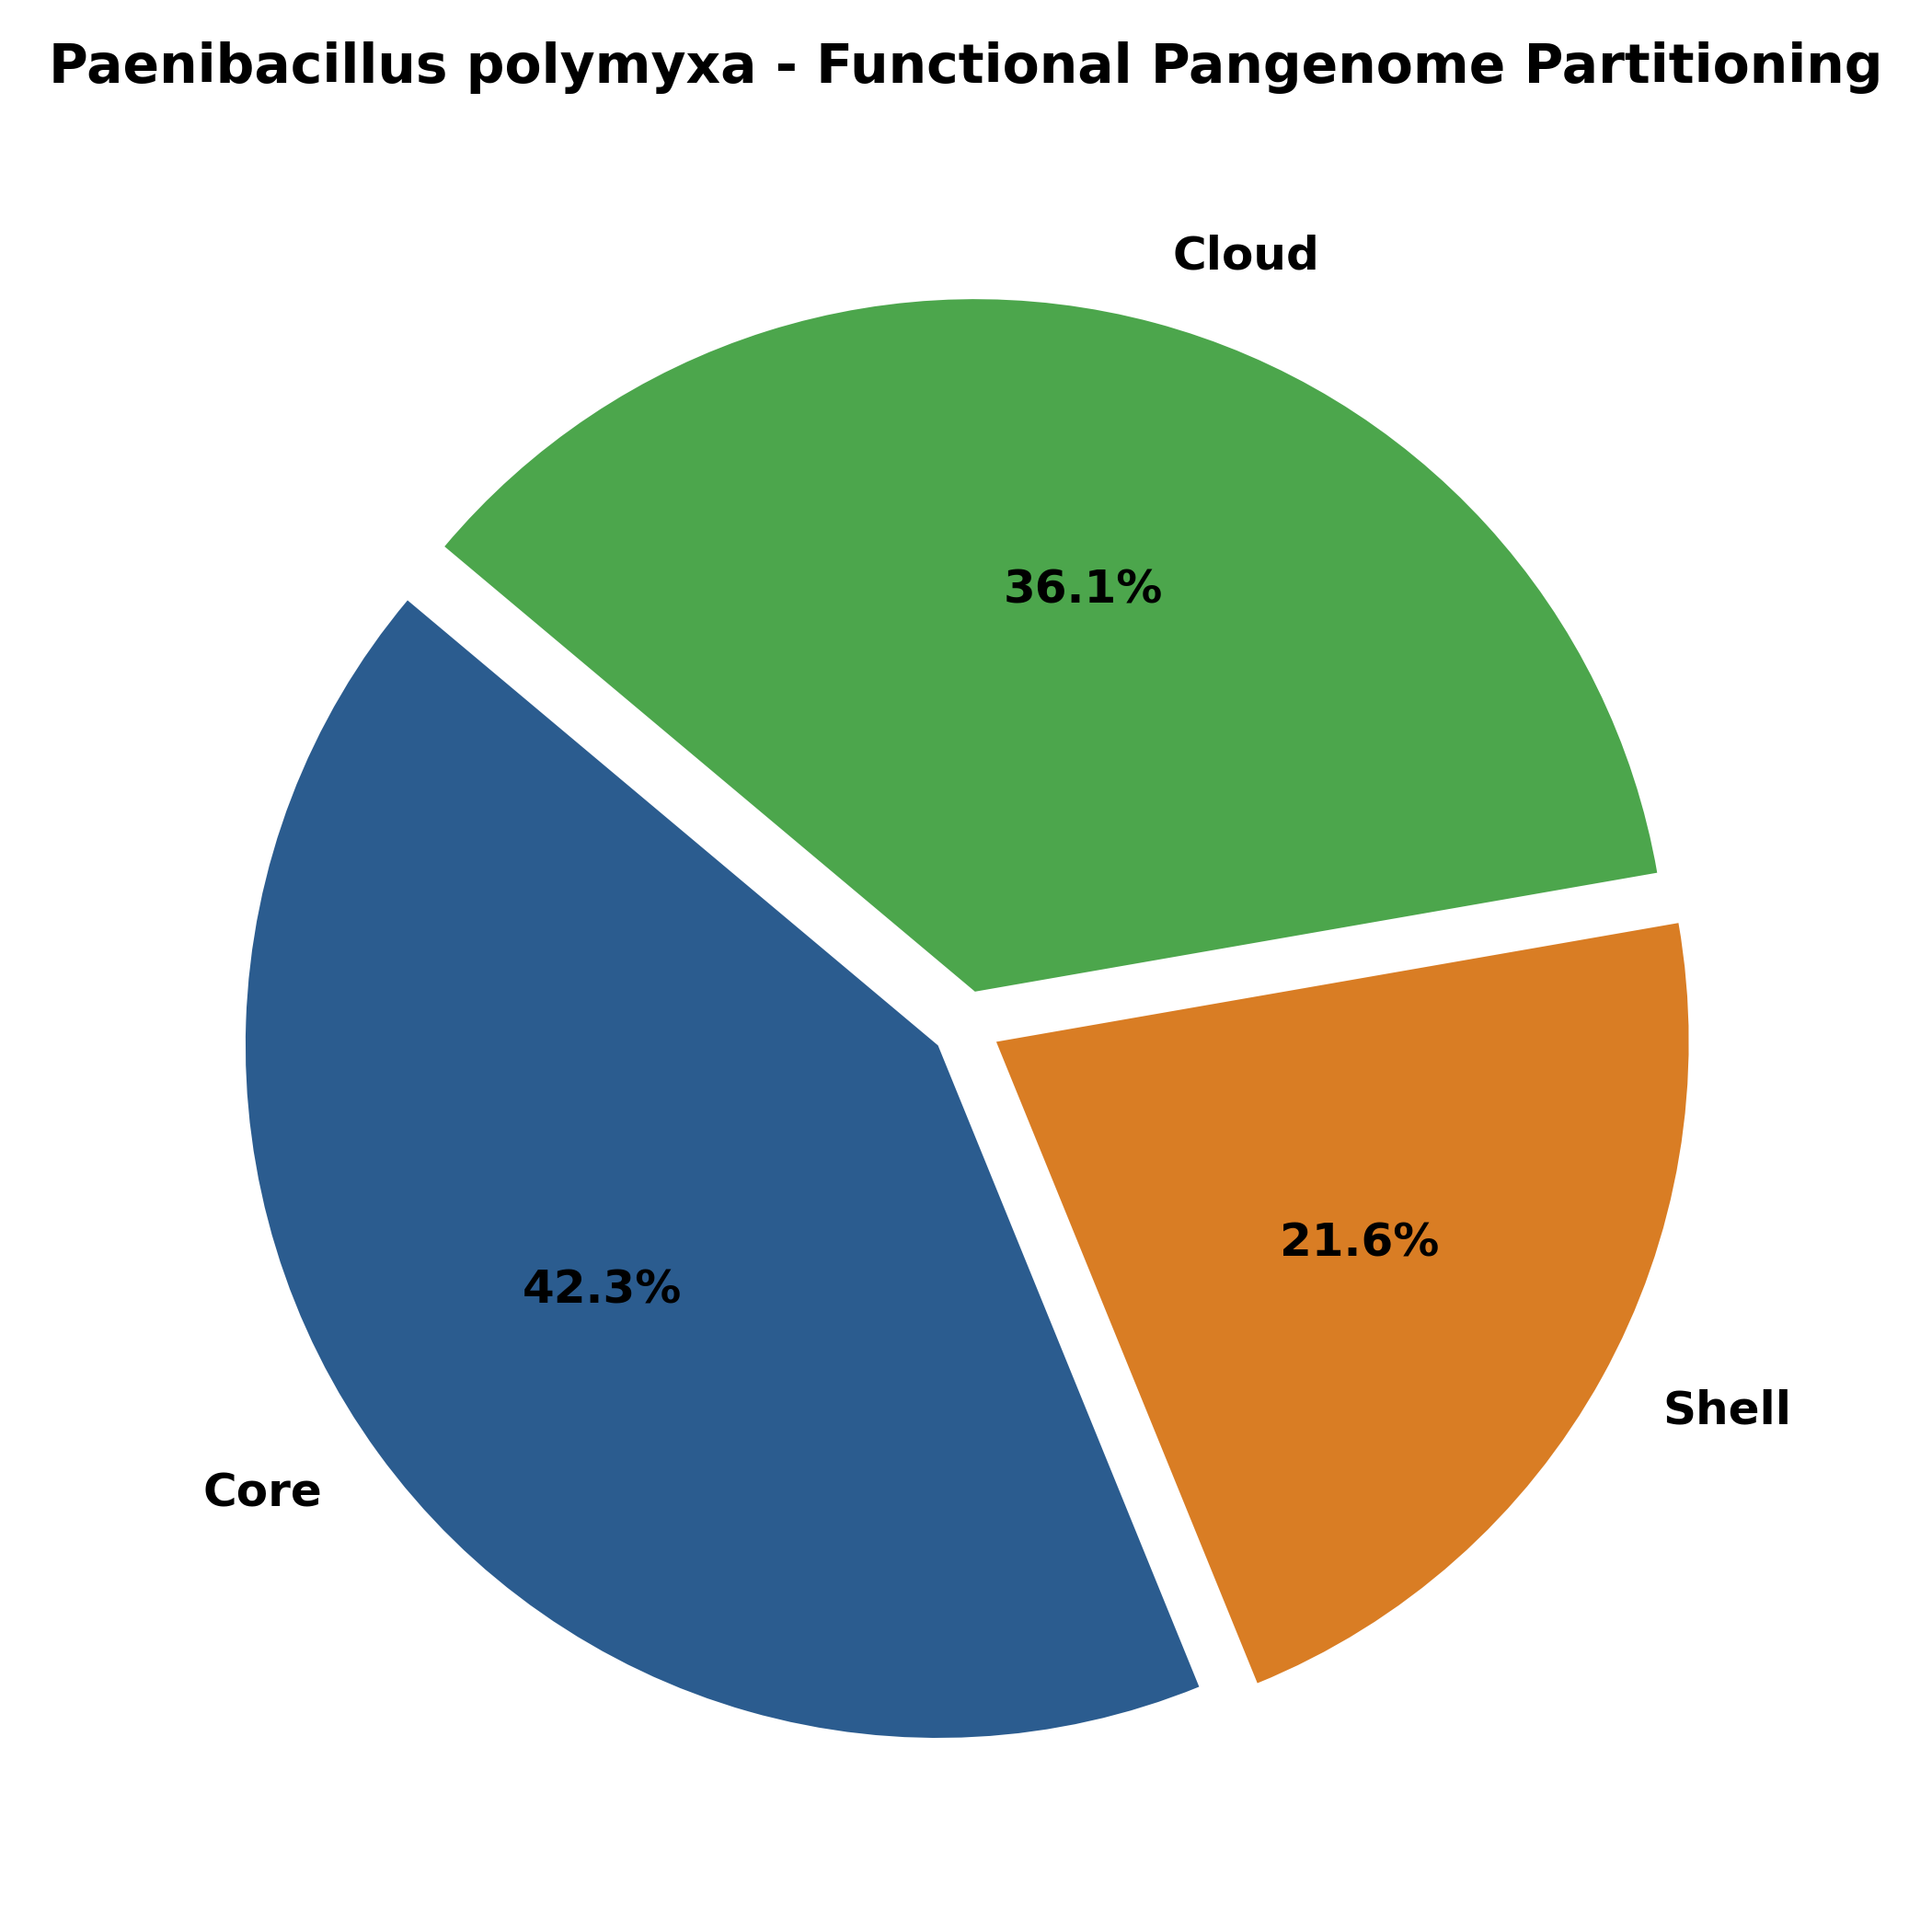

In [9]:
# Generate Pangenome Matrix and Visualize Results
import src.matrix_generator as mg
from src.pangenome_statistics import run_pangenome_analytics
import config as config
from IPython.display import Image, display

# 1. Generate Binary Matrix
pangenome_matrix = mg.run_matrix_generation()

# Confirm matrix shape against expected dimensions
print(f"Matrix shape in memory: {pangenome_matrix.shape}")

# 2. Stratify Pangenome Layers and Render Summary Table
stats_results = run_pangenome_analytics()
display(stats_results["summary_table"])
display(Image(filename=config.PIE_CHART_PLOT))

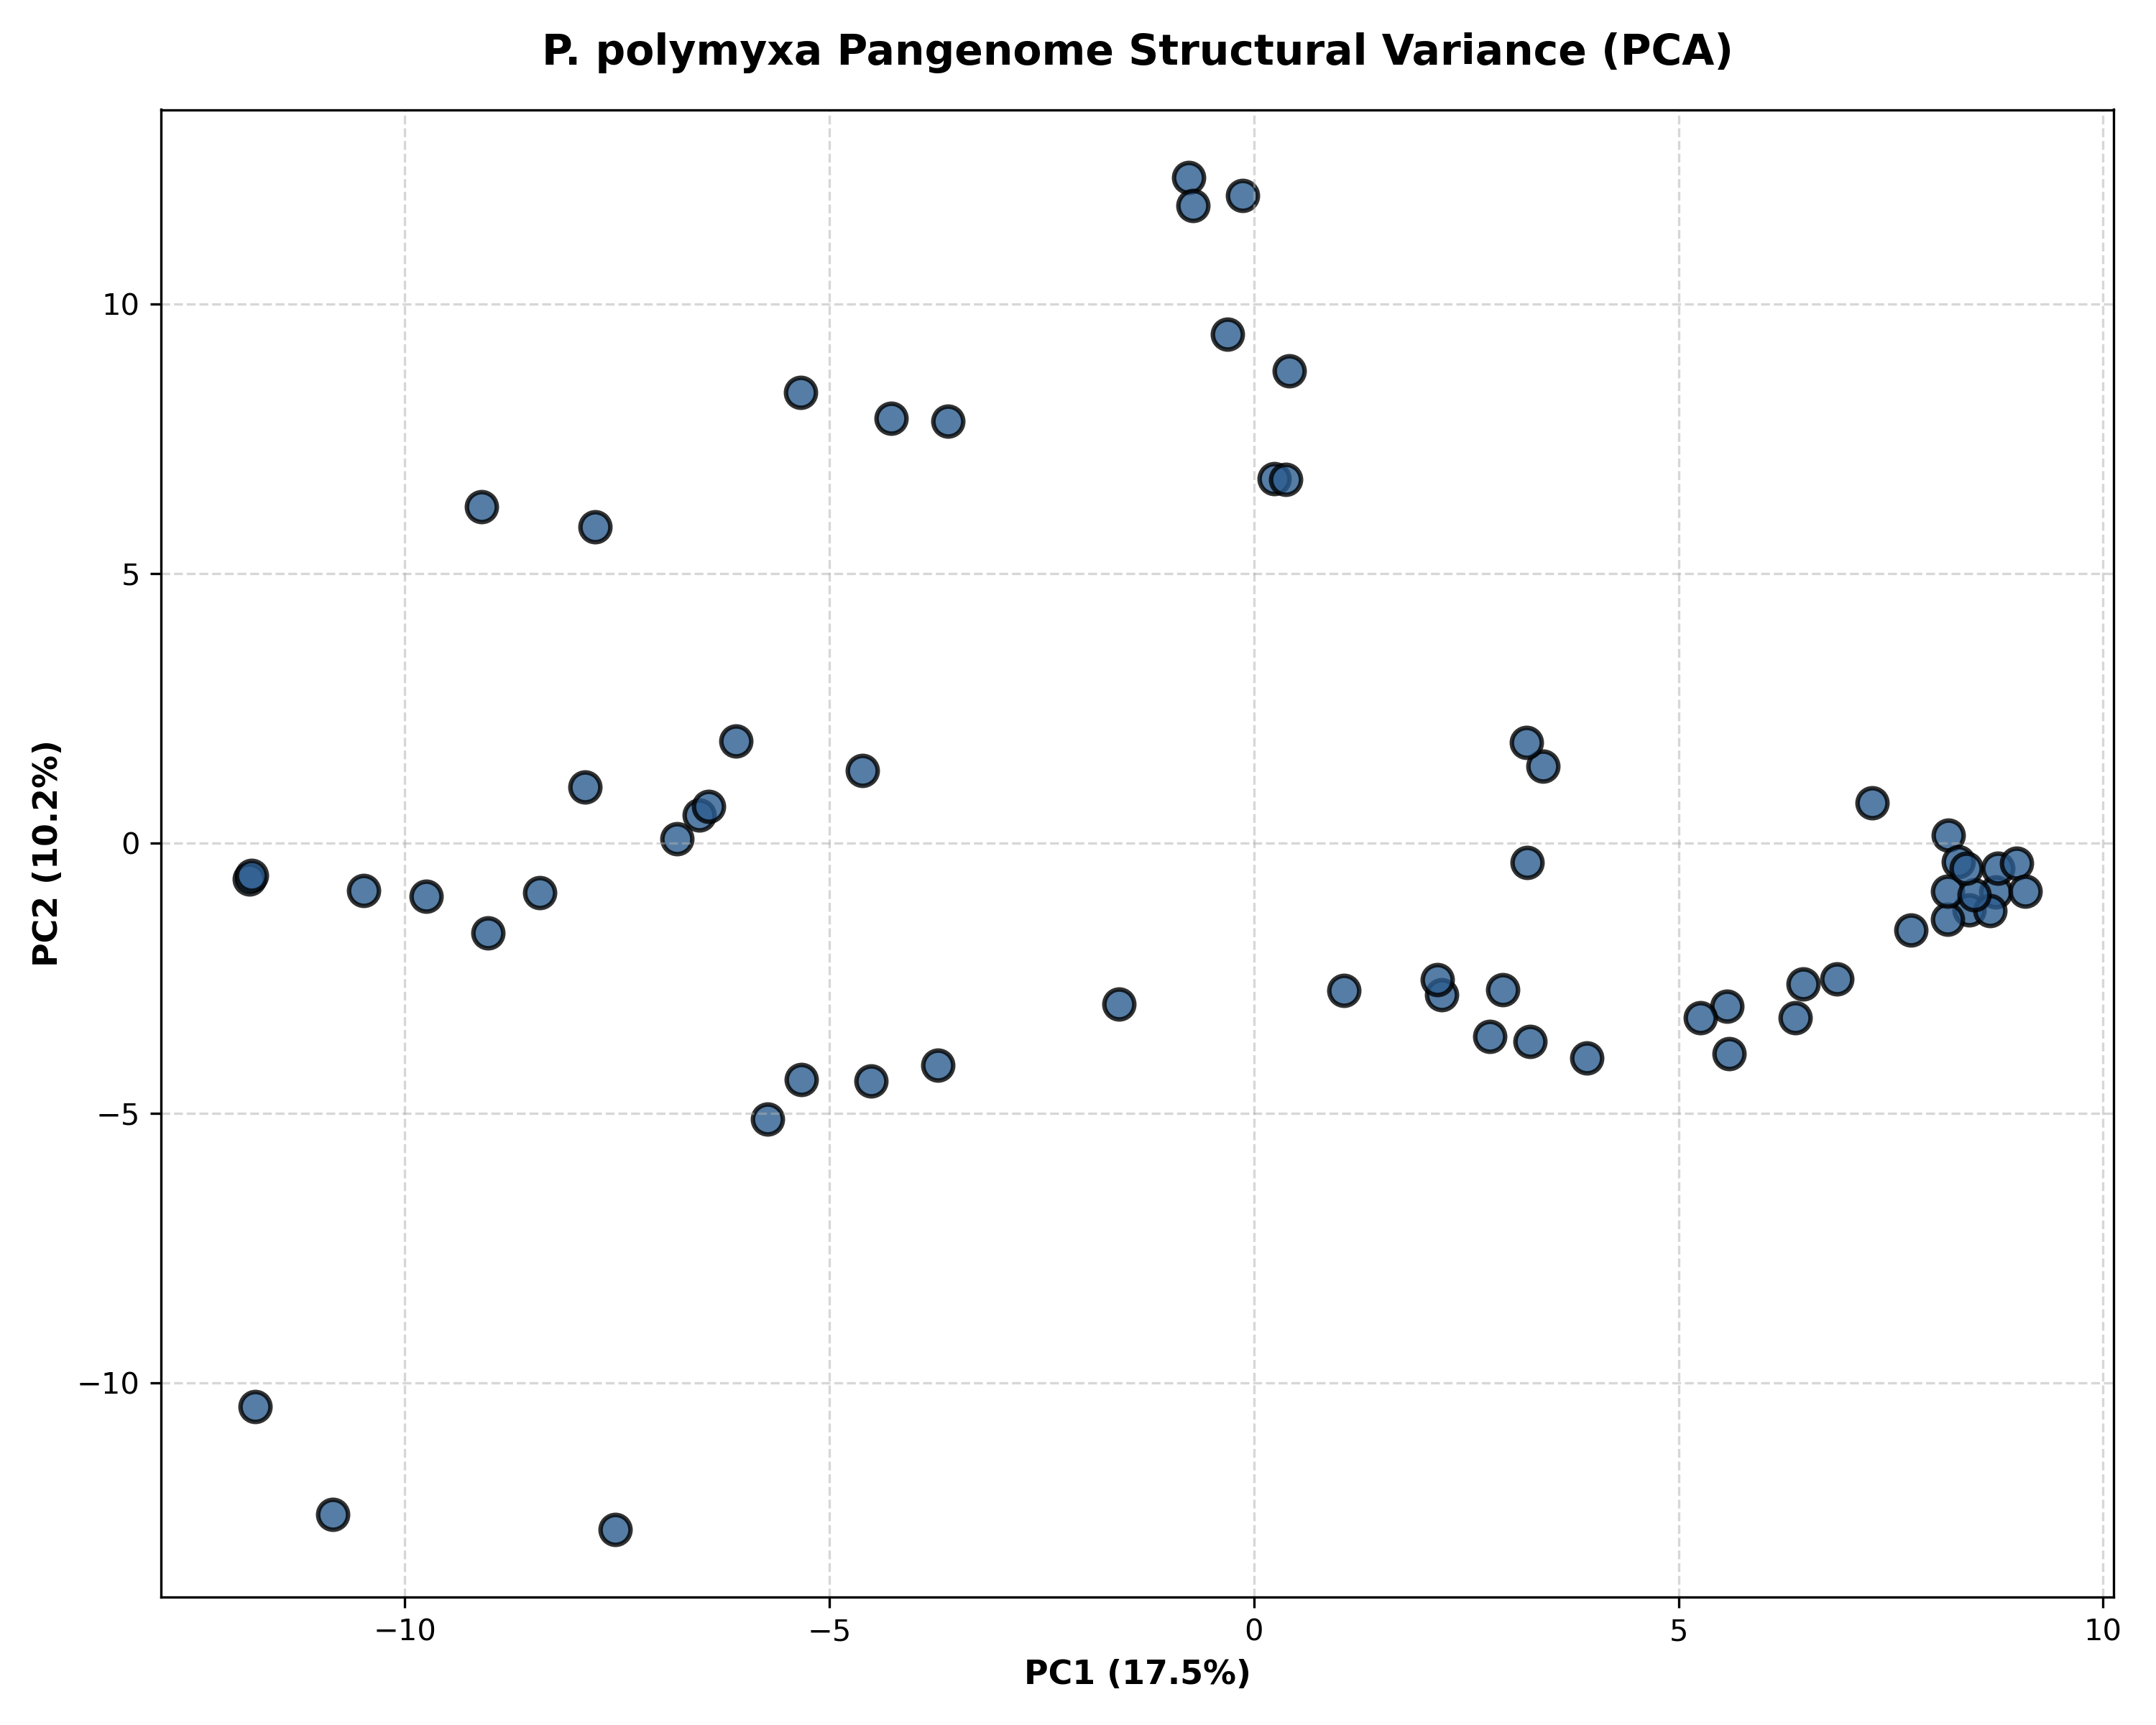

In [10]:
# Principal Component Analysis
from src.pca_analysis import PangenomePCA
import config as config
from IPython.display import Image, display

# Initialize PCA analysis pipeline
analyzer = PangenomePCA()

# Execute dimensionality reduction on pangenome matrix
df_pca = analyzer.run_analysis(matrix_path=config.MATRIX_CSV)

# Display the PCA plot
display(Image(filename=config.PCA_PLOT))

In [11]:
# Load pangenome binary matrix and generate initial PCA coordinate space
import config as config
import pandas as pd

df_matrix = pd.read_csv(config.MATRIX_CSV, index_col=0)

x_lab = analyzer.get_x_label()
y_lab = analyzer.get_y_label()

In [12]:
# Execute K-Means and Hierarchical Cluster Analysis on PCA coordinates
import src.hca_analysis as hca
import src.kmeans_clustering as kmeans

df_kmeans = kmeans.run_kmeans_clustering(
    df_pca,
    k=4,
    xlabel=x_lab,
    ylabel=y_lab,
)
df_hca_clusters = hca.run_hca_clustering(n_clusters=4)

c:\Users\eric1\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\eric1\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\eric1\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\eric1\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

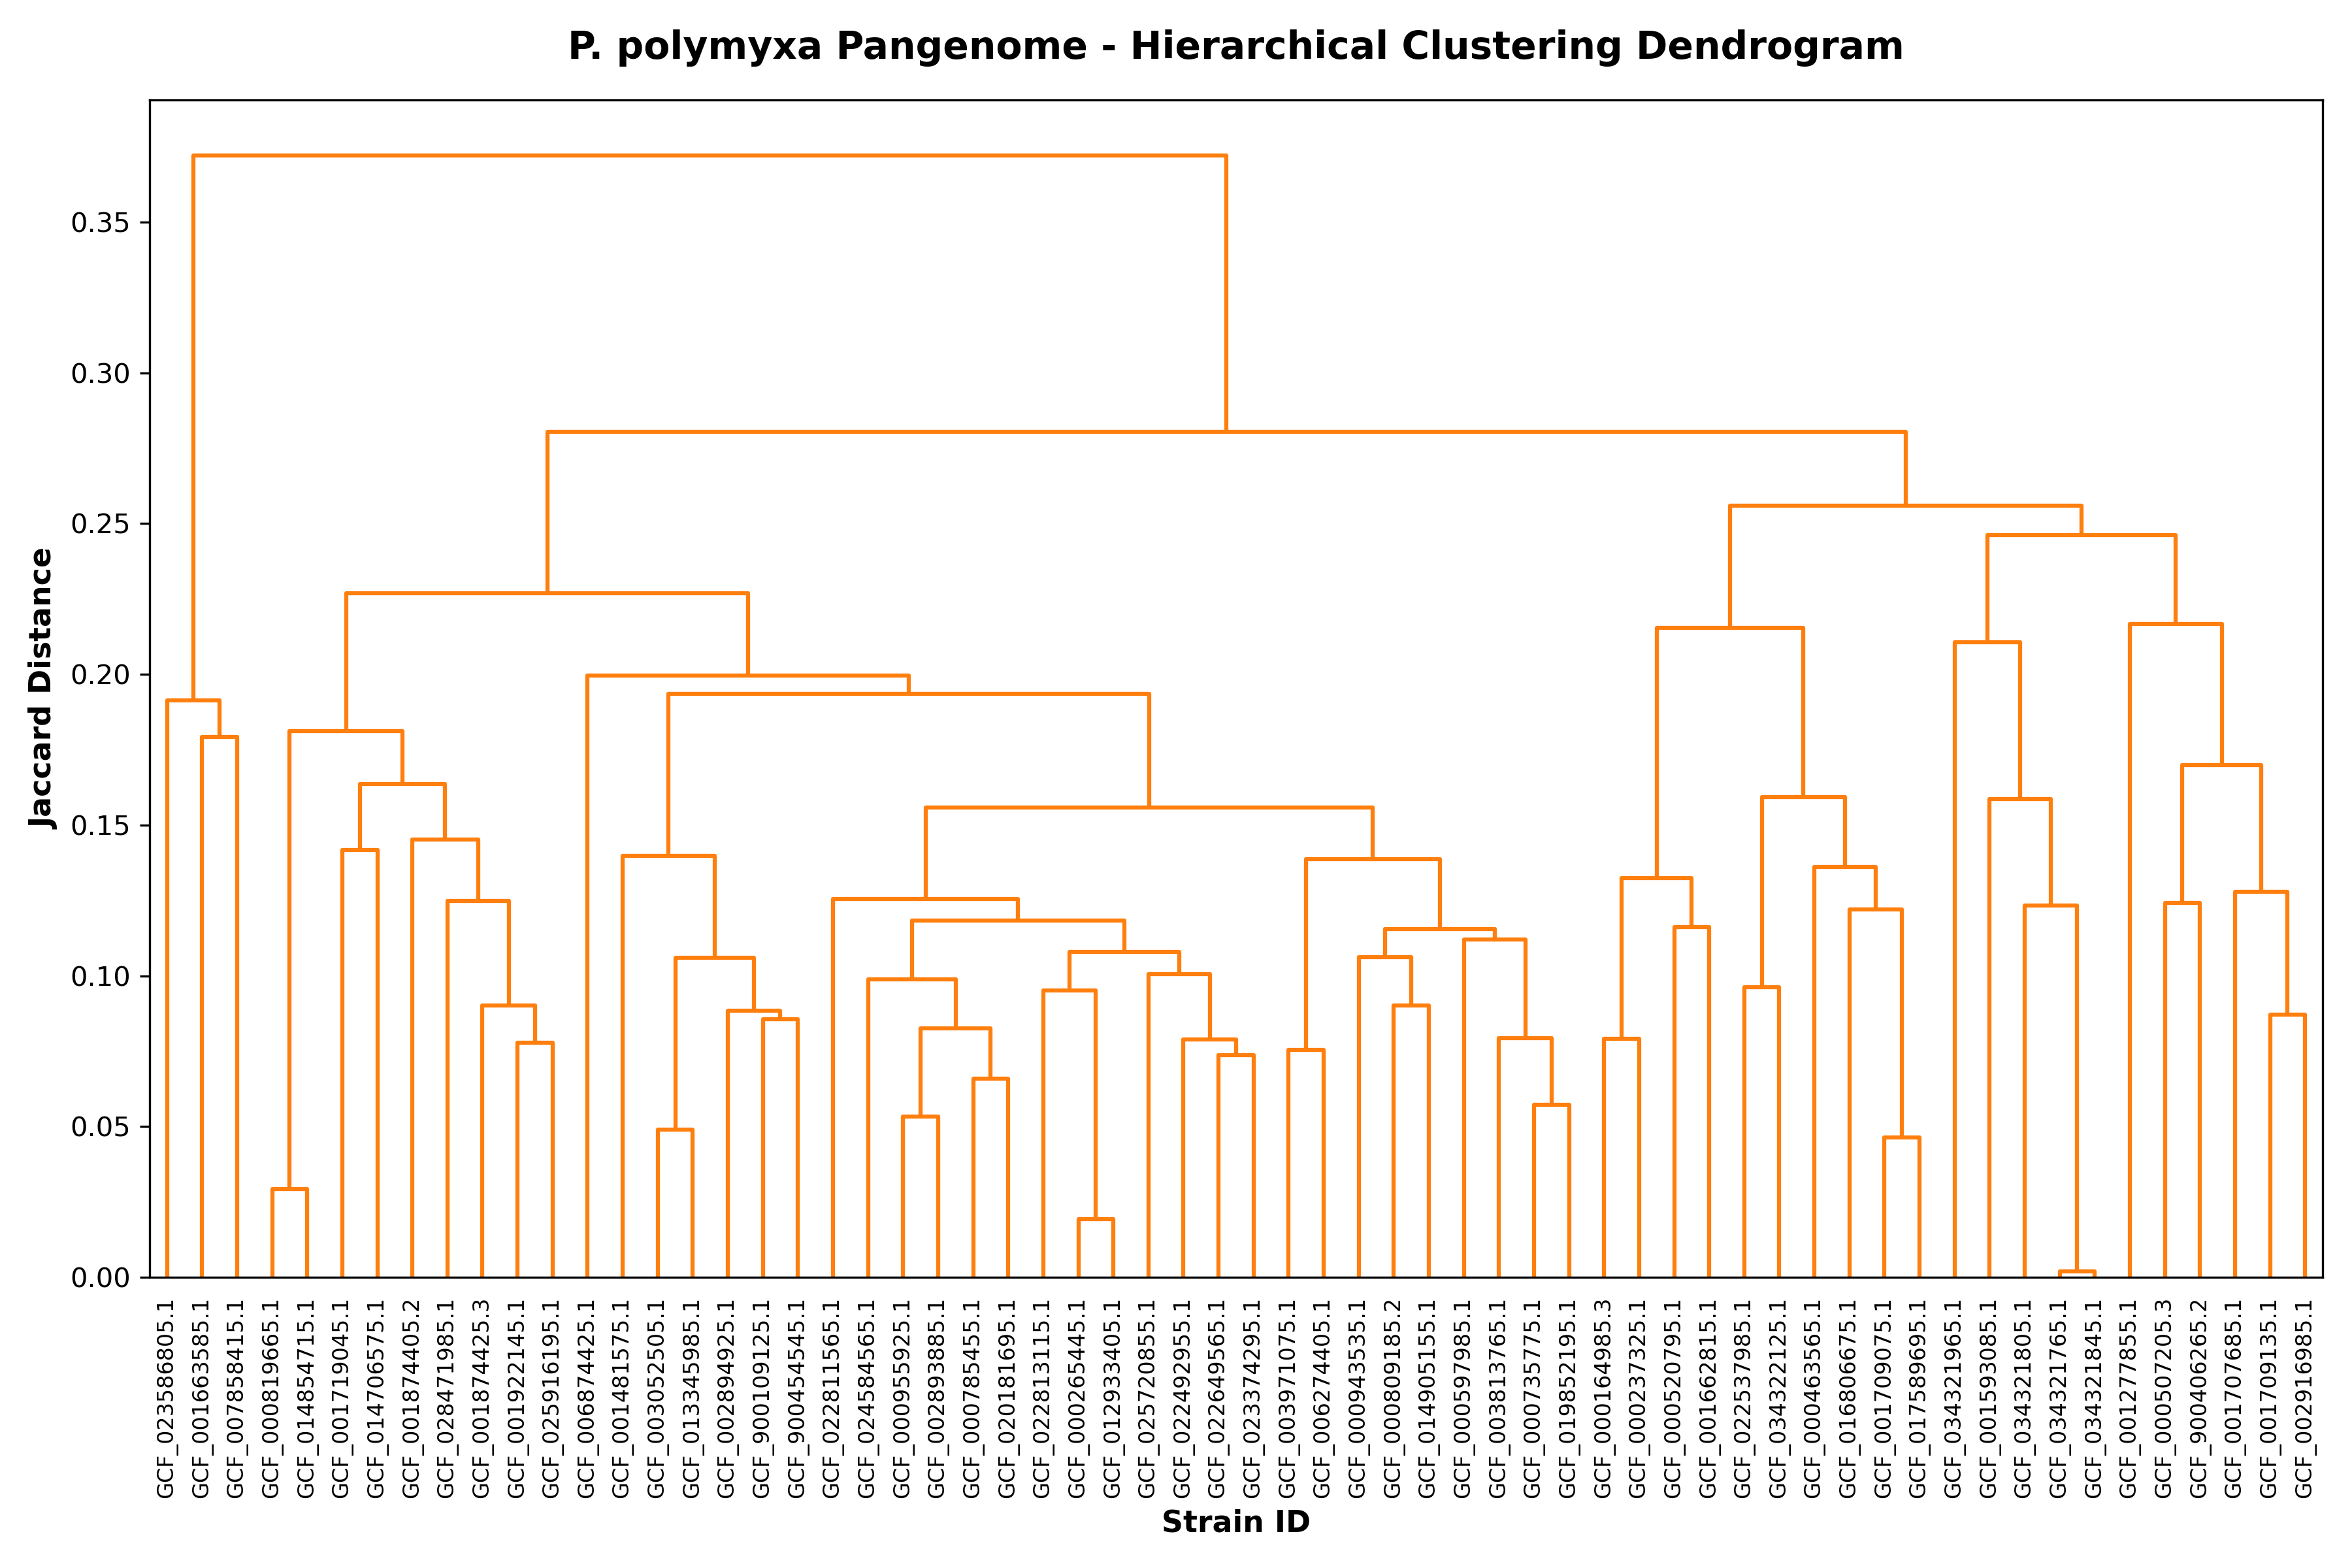

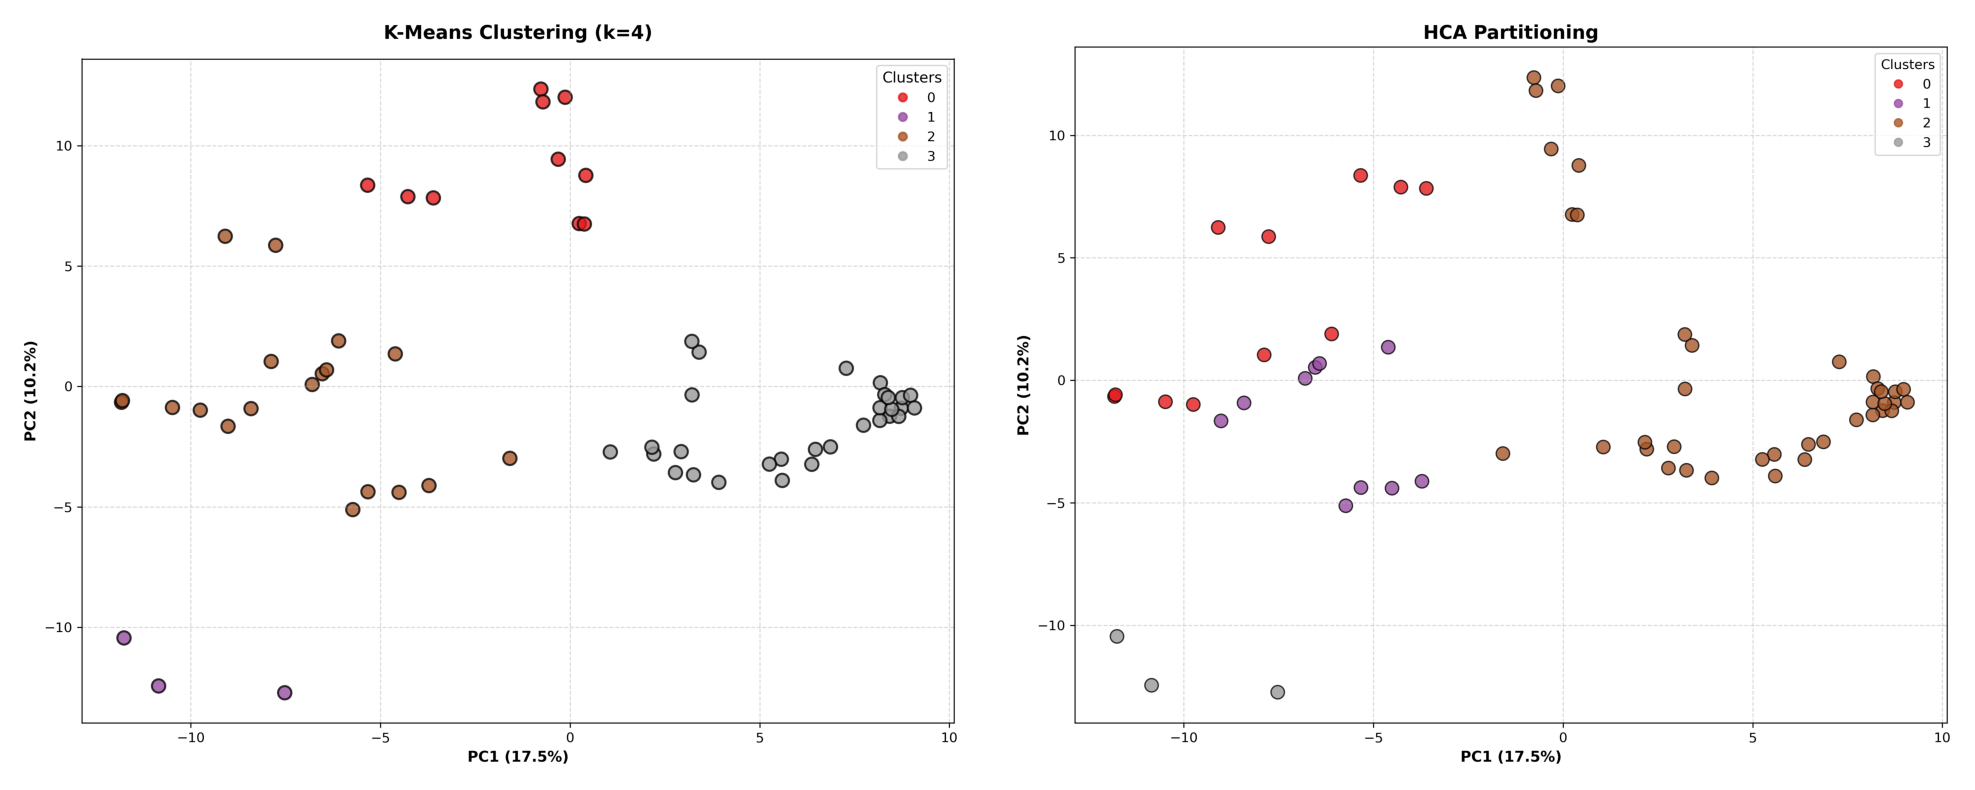

In [13]:
# Generate cluster overlays, dendrograms, and side-by-side comparative plots
import matplotlib.pyplot as plt
import src.hca_analysis as hca
import config as config
from IPython.display import Image, display

hca.plot_hca_on_pca(
    df_pca, df_hca_clusters, config.PCA_HCA_PLOT, xlabel=x_lab, ylabel=y_lab
)

display(Image(filename=config.HCA_DENDROGRAM_PLOT))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].imshow(plt.imread(config.PCA_KMEANS_PLOT))
axes[0].axis("off")

axes[1].imshow(plt.imread(config.PCA_HCA_PLOT))
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [14]:
# Filter and print strain identifiers belonging to identified outgroup clusters
hca_outgroup = df_hca_clusters[df_hca_clusters["HCA_Cluster"] == 3].index.tolist()
kmeans_outgroup = df_kmeans[df_kmeans["Cluster"] == 1].index.tolist()

print(f"HCA Outgroup Strains ({len(hca_outgroup)}): {hca_outgroup}")
print(f"K-Means Outgroup Strains ({len(kmeans_outgroup)}): {kmeans_outgroup}")

HCA Outgroup Strains (3): ['GCF_001663585.1', 'GCF_007858415.1', 'GCF_023586805.1']
K-Means Outgroup Strains (3): ['GCF_001663585.1', 'GCF_007858415.1', 'GCF_023586805.1']


In [ ]:
# Extract and Display Top Principal Component Loading Drivers
import pandas as pd
import config

# Load binary presence-absence matrix to map feature names against loadings
df_matrix = pd.read_csv(config.MATRIX_CSV, index_col=0)

# Compute feature loadings to identify top genes driving variance along PC1 and PC2
top_pc1, top_pc2 = analyzer.extract_loadings(df_matrix.columns, top_n=10)

print("Top 10 PC1 Driver Genes:")
display(top_pc1)

print("\nTop 10 PC2 Driver Genes:")
display(top_pc2)

Top 10 PC1 Driver Genes:


,Gene_Name,PC1_Loading,PC2_Loading,Abs_PC1,Abs_PC2
2320,log_family_protein,0.063024,0.018968,0.063024,0.018968
3938,tigr00730_family_rossman_fold_protein,-0.063024,-0.018968,0.063024,0.018968
4257,y_family_dna_polymerase,0.060860,-0.021861,0.060860,0.021861
3053,plp_dependent_aminotransferase_family_protein,-0.060118,-0.017066,0.060118,0.017066
4363,ylmh_family_rna_binding_protein,0.059843,0.024608,0.059843,0.024608
3412,ribosomal_maturation_yjga_family_protein,0.059843,0.024608,0.059843,0.024608
1206,duf2809_domain_containing_protein,-0.059843,-0.024608,0.059843,0.024608
271,aminotransferase_like_domain_containing_protein,0.059843,0.024608,0.059843,0.024608
3381,rhamnulokinase,0.058763,-0.038551,0.058763,0.038551
3064,poly_ethylene_terephthalate_hydrolase_family_p...,0.058712,-0.027182,0.058712,0.027182



Top 10 PC2 Driver Genes:


,Gene_Name,PC1_Loading,PC2_Loading,Abs_PC1,Abs_PC2
4447,zinc_dependent_alcohol_dehydrogenase_family_pr...,-0.039772,0.065043,0.039772,0.065043
1703,fructoselysine_6_kinase,0.022649,-0.064880,0.022649,0.064880
1330,duf4395_domain_containing_protein,-0.035741,0.064699,0.035741,0.064699
3797,substrate_binding_periplasmic_protein,-0.035741,0.064699,0.035741,0.064699
3093,potassium_transporting_atpase_subunit_f,-0.043001,0.064033,0.043001,0.064033
3764,srpbcc_family_protein,-0.027152,0.063840,0.027152,0.063840
2550,monooxygenase,0.017660,-0.063658,0.017660,0.063658
281,ant_6,0.046754,-0.063500,0.046754,0.063500
3418,ric,-0.046754,0.063500,0.046754,0.063500
1361,duf542_domain_containing_protein,0.046754,-0.063500,0.046754,0.063500


In [16]:
# Calculate and Display Gene Enrichment Profiles Across HCA Clusters
import pandas as pd
import config

# Load pre-computed hierarchical clustering assignments
df_hca_clusters = pd.read_csv(config.HCA_CLUSTERS_CSV, index_col="Strain_ID")

# Merge clustering metadata with the binary presence-absence matrix
df_combined = df_matrix.join(df_hca_clusters)

# Extract top gene lists from upstream component loading analyses
pc1_genes = top_pc1["Gene_Name"].tolist()
pc2_genes = top_pc2["Gene_Name"].tolist()

# Compute mean gene presence frequency (0.0 to 1.0) for driver genes within each cluster
cluster_pc1_profile = df_combined.groupby("HCA_Cluster")[pc1_genes].mean()
cluster_pc2_profile = df_combined.groupby("HCA_Cluster")[pc2_genes].mean()

# Render transposed enrichment profiles for structural interpretation
print("\nAverage presence (0.0 - 1.0) of top PC1 driver genes per cluster:")
display(cluster_pc1_profile.T)

print("\nAverage presence (0.0 - 1.0) of top PC2 driver genes per cluster:")
display(cluster_pc2_profile.T)


Average presence (0.0 - 1.0) of top PC1 driver genes per cluster:


HCA_Cluster,0,1,2,3
log_family_protein,0.090909,0.0,0.947368,0.000000
tigr00730_family_rossman_fold_protein,0.909091,1.0,0.052632,1.000000
y_family_dna_polymerase,0.000000,0.0,0.710526,0.000000
plp_dependent_aminotransferase_family_protein,0.818182,0.9,0.078947,1.000000
ylmh_family_rna_binding_protein,0.181818,0.1,0.947368,0.000000
ribosomal_maturation_yjga_family_protein,0.181818,0.1,0.947368,0.000000
duf2809_domain_containing_protein,0.818182,0.9,0.052632,1.000000
aminotransferase_like_domain_containing_protein,0.181818,0.1,0.947368,0.000000
rhamnulokinase,0.000000,0.0,0.736842,0.333333
poly_ethylene_terephthalate_hydrolase_family_protein,0.000000,0.0,0.657895,0.000000



Average presence (0.0 - 1.0) of top PC2 driver genes per cluster:


HCA_Cluster,0,1,2,3
zinc_dependent_alcohol_dehydrogenase_family_protein,0.909091,0.5,0.184211,0.0
fructoselysine_6_kinase,0.363636,0.5,0.763158,1.0
duf4395_domain_containing_protein,1.000000,0.2,0.184211,0.0
substrate_binding_periplasmic_protein,1.000000,0.2,0.184211,0.0
potassium_transporting_atpase_subunit_f,0.909091,0.6,0.184211,0.0
srpbcc_family_protein,0.909091,0.0,0.210526,0.0
monooxygenase,0.363636,1.0,0.815789,1.0
ant_6,0.000000,0.4,0.815789,1.0
ric,1.000000,0.6,0.184211,0.0
duf542_domain_containing_protein,0.000000,0.4,0.815789,1.0


In [17]:
# Calculate Functional Profile Scores and Merge Cluster Profiles
import src.functional_profiler as pp
import config as config
import pandas as pd

# Establish screening keywords for targeted functional traits (e.g., secondary metabolites, resistance determinants, and metabolic operons)
TARGET_KEYWORDS = [
    "toxin",
    "hemolysin",
    "virulence",
    "resistance",
    "antibiotic",
    "beta_lactamase",
    "bacteriocin",
    "penicillin_binding",
    "bacitracin",
    "paenilan",
    "paenibacillin",
]


# Run the profiler module to compute target functional scores and associated gene counts
df_target = pp.run_target_profiling(target_keywords=TARGET_KEYWORDS)

# Load cluster assignments and merge with target metrics and PCA coordinates
df_hca_clusters = pd.read_csv(config.HCA_CLUSTERS_CSV, index_col="Strain_ID")
df_final_profile = df_target.join(df_hca_clusters).join(df_kmeans, rsuffix="_kmeans")

# Rename ambiguous cluster column to maintain explicit method tracking
df_final_profile = df_final_profile.rename(columns={"Cluster": "KMeans_Cluster"})

# Reorder columns for unified analytical inspection and rename metric columns to reflect broader profiling
df_final_profile = df_final_profile.rename(
    columns={
        "Risk_Associated_Gene_Count": "Target_Associated_Gene_Count",
        "Pathogenicity_Risk_Index": "Target_Functional_Index",
    }
)

column_order = [
    "Target_Associated_Gene_Count",
    "Target_Functional_Index",
    "PC1",
    "PC2",
    "HCA_Cluster",
    "KMeans_Cluster",
]

df_final_profile = df_final_profile[column_order]

display(df_final_profile.head(10))

,Target_Associated_Gene_Count,Target_Functional_Index,PC1,PC2,HCA_Cluster,KMeans_Cluster
GCF_001707685.1,29,1.000,-5.337558,8.361183,0,0
GCF_006274405.1,28,0.966,8.169031,-1.410821,2,3
GCF_003971075.1,27,0.931,3.254390,-3.670401,2,3
GCF_001709135.1,27,0.931,-4.276718,7.884708,0,0
GCF_001709075.1,26,0.897,-4.609549,1.352788,1,2
GCF_017589695.1,26,0.897,-6.421629,0.688195,1,2
GCF_034322125.1,26,0.897,-9.019261,-1.654397,1,2
GCF_022811565.1,25,0.862,8.298529,-0.338667,2,3
GCF_025916195.1,25,0.862,-0.714751,11.823193,2,0
GCF_028471985.1,25,0.862,-0.312714,9.440202,2,0
